# Tree Models
### The following models will be tested
- Random Forest
- XGBoost

In [38]:
import pandas as pd
import numpy as np
import torch
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import gc

### Load and Clean Data

In [2]:
tree_feature_set = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'hour', 'day_of_week', 'month', 
    'is_weekend', 'is_am_rush_hour', 'is_pm_rush_hour',
    'latitude', 'longitude', 'dist_to_union_km',
    'cluster_east_end', 'cluster_west_end', 'cluster_uptown', 'cluster_scarborough',
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    'capacity', 'is_charging_station',
    'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]

In [3]:
print("--- Loading Data ---")

# A. Load Sample Data
raw_train_sample_full = pd.read_csv('train_sample_2.csv')

# B. Load Full Data & Test Data
raw_train_full = pd.read_csv('train_2.csv')
raw_test = pd.read_csv('test_2.csv')

# C. Load Validation Data
raw_val = pd.read_csv('val_2.csv')

print(f"Full Train Shape: {raw_train_full.shape}")
print(f"Validation Shape: {raw_val.shape}")
print(f"Test Shape: {raw_test.shape}")

--- Loading Data ---
Full Train Shape: (10865904, 49)
Validation Shape: (1381274, 49)
Test Shape: (1338746, 49)


In [5]:
raw_train_sample = raw_train_sample_full.sample(frac=0.5, random_state=42)
print(f"Sample Train Shape: {raw_train_sample.shape}")

Sample Train Shape: (543295, 49)


### Preprocess Data

In [6]:
# Separate Target (y) and Features (X)
# Sample
X_train_sample = raw_train_sample[tree_feature_set]
y_train_sample = raw_train_sample['trips_started']

# Full
X_train_full = raw_train_full[tree_feature_set]
y_train_full = raw_train_full['trips_started']

# Test
X_test = raw_test[tree_feature_set]
y_test = raw_test['trips_started']

# Validation
X_val = raw_val[tree_feature_set]
y_val = raw_val['trips_started']

print(f"Features used for RF: {X_train_sample.shape[1]}")

Features used for RF: 36


## Random Forest

### Hyperparameter Tuning

In [7]:
print("\n--- Tuning Random Forest on Sample Data ---")

# Define the grid
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [25, 35, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 0.5]
}

rf_tuner = RandomForestRegressor(
    random_state=42, 
    n_jobs=6,
    max_samples=0.8
) 

# Run Random Search
random_search = RandomizedSearchCV(
    estimator=rf_tuner,
    param_distributions=param_dist,
    n_iter=15, 
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train_sample, y_train_sample)
best_params_rf = random_search.best_params_
print(f"Best Parameters: {best_params_rf}")


--- Tuning Random Forest on Sample Data ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40}


### Training and Evaluation

In [8]:
# --- Model A: Trained on Sample Data ---
print("\n--- Training RF on Sample Data ---")
rf_model_sample = RandomForestRegressor(
    **best_params_rf, 
    random_state=42, 
    n_jobs=1,
    verbose=2
)
rf_model_sample.fit(X_train_sample, y_train_sample)

# --- Model B: Trained on Full Data ---
print("\n--- Training RF on Full Data ---")
rf_model_full = RandomForestRegressor(
    **best_params_rf, 
    random_state=42, 
    n_jobs=1,
    verbose=2
)
rf_model_full.fit(X_train_full, y_train_full)


--- Training RF on Sample Data ---
building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   23.5s


building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:  1.6min


building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  2.0min finished



--- Training RF on Full Data ---
building tree 1 of 200
building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  9.3min


building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81 of 200
building tree 82

[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed: 37.3min


building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed: 47.6min finished


,n_estimators,200
,criterion,'squared_error'
,max_depth,40
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Generate Predictions

In [40]:
# --- Sample Model Predictions ---
# Sample Model
y_pred_sample_train_log = rf_model_sample.predict(X_train_sample)
y_pred_sample_on_val_log = rf_model_sample.predict(X_val)

# Full Model
y_pred_full_train_log = rf_model_full.predict(X_train_full)
y_pred_full_on_val_log = rf_model_full.predict(X_val)

# --- INVERSE TRANSFORM (Log -> Real Bikes) ---
# Sample Model Real
y_pred_sample_train_real = np.maximum(np.expm1(y_pred_sample_train_log), 0)
y_pred_sample_on_val_real = np.maximum(np.expm1(y_pred_sample_on_val_log), 0)

# Full Model Real
y_pred_full_train_real = np.maximum(np.expm1(y_pred_full_train_log), 0)
y_pred_full_on_val_real = np.maximum(np.expm1(y_pred_full_on_val_log), 0)

# --- 3. INVERSE TRANSFORM ACTUALS ---
# We must compare "Real Predictions" vs "Real Actuals"
y_train_sample_real = np.expm1(y_train_sample)
y_train_full_real = np.expm1(y_train_full)
y_val_real = np.expm1(y_val) # Corrected: We compare val predictions to y_val, not y_test

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   14.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   18.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    3.9s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   15.5s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   19.2s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:  5.5min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  6.8min finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   11.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   44.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   54.3s finished


### Calculate Metrics and Evaluate

In [41]:
# Sample Model Scores
rmse_sample_train = np.sqrt(mean_squared_error(y_train_sample_real, y_pred_sample_train_real))
r2_sample_train = r2_score(y_train_sample_real, y_pred_sample_train_real)

rmse_sample_val = np.sqrt(mean_squared_error(y_val_real, y_pred_sample_on_val_real))
r2_sample_val = r2_score(y_val_real, y_pred_sample_on_val_real)

# Full Model Scores
rmse_full_train = np.sqrt(mean_squared_error(y_train_full_real, y_pred_full_train_real))
r2_full_train = r2_score(y_train_full_real, y_pred_full_train_real)

rmse_full_val = np.sqrt(mean_squared_error(y_val_real, y_pred_full_on_val_real))
r2_full_val = r2_score(y_val_real, y_pred_full_on_val_real)

# --- Print Report ---
print("\n" + "="*65)
print("MODEL CONFIGURATION (Best Params)")
print("="*65)
try:
    for param, value in best_params_rf.items():
        print(f"{param:<25}: {value}")
except NameError:
    print("best_params_rf not defined (using manual params?)")

print("\n" + "="*65)
print(f"{'METRIC (Real Scale)':<20} | {'RF (Sample Trained)':<20} | {'RF (Full Trained)':<20}")
print("="*65)
print(f"{'Train RMSE':<20} | {rmse_sample_train:<20.4f} | {rmse_full_train:<20.4f}")
print(f"{'Val RMSE':<20} | {rmse_sample_val:<20.4f} | {rmse_full_val:<20.4f}")
print("-" * 65)
print(f"{'Train R^2':<20} | {r2_sample_train:<20.4f} | {r2_full_train:<20.4f}")
print(f"{'Val R^2':<20} | {r2_sample_val:<20.4f} | {r2_full_val:<20.4f}")
print("="*65)


MODEL CONFIGURATION (Best Params)
n_estimators             : 200
min_samples_split        : 10
min_samples_leaf         : 2
max_features             : sqrt
max_depth                : 40

METRIC (Real Scale)  | RF (Sample Trained)  | RF (Full Trained)   
Train RMSE           | 1.0851               | 1.0398              
Val RMSE             | 1.3792               | 1.2838              
-----------------------------------------------------------------
Train R^2            | 0.6946               | 0.7208              
Val R^2              | 0.5291               | 0.5919              


### Final Test for Random Forest

In [42]:
# --- 1. GENERATE PREDICTIONS (Log Scale) ---
# Sample Model
y_pred_sample_test_log  = rf_model_sample.predict(X_test)

# Full Model
y_pred_full_test_log    = rf_model_full.predict(X_test)

# --- 2. INVERSE TRANSFORM (Unclamped first) ---
# Sample Model
raw_pred_sample_train_rf = np.expm1(y_pred_sample_train_log)
raw_pred_sample_val_rf   = np.expm1(y_pred_sample_on_val_log)
raw_pred_sample_test_rf  = np.expm1(y_pred_sample_test_log)

# Full Model
raw_pred_full_train_rf   = np.expm1(y_pred_full_train_log)
raw_pred_full_val_rf     = np.expm1(y_pred_sample_on_val_log)
raw_pred_full_test_rf    = np.expm1(y_pred_full_test_log)

# --- 3. DIAGNOSTIC: CHECK FOR NEGATIVE PREDICTIONS ---
neg_sample = (raw_pred_sample_test_rf < 0).sum()
neg_full   = (raw_pred_full_test_rf < 0).sum()

pct_sample = (neg_sample / len(raw_pred_sample_test_rf)) * 100
pct_full   = (neg_full / len(raw_pred_full_test_rf)) * 100

# --- 4. CLAMP NEGATIVES (For Final Metrics) ---
# Applying the unclamped logic as requested
y_pred_sample_train_real = raw_pred_sample_train_rf
y_pred_sample_val_real   = raw_pred_sample_val_rf
y_pred_sample_test_real  = raw_pred_sample_test_rf

y_pred_full_train_real   = raw_pred_full_train_rf
y_pred_full_val_real     = raw_pred_full_val_rf
y_pred_full_test_real    = raw_pred_full_test_rf

# --- 5. INVERSE TRANSFORM ACTUALS ---
# Ensure actuals are on the real scale
y_train_sample_real = np.expm1(y_train_sample)
y_train_full_real   = np.expm1(y_train_full)
y_val_real          = np.expm1(y_val)
y_test_real         = np.expm1(y_test)

# --- 6. CALCULATE METRICS ---
# Helper function to keep code clean
def get_scores(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

# Sample Model Scores
rmse_sample_train, mae_sample_train, r2_sample_train = get_scores(y_train_sample_real, y_pred_sample_train_real)
rmse_sample_val, mae_sample_val, r2_sample_val     = get_scores(y_val_real, y_pred_sample_val_real)
rmse_sample_test, mae_sample_test, r2_sample_test   = get_scores(y_test_real, y_pred_sample_test_real)

# Full Model Scores
rmse_full_train, mae_full_train, r2_full_train = get_scores(y_train_full_real, y_pred_full_train_real)
rmse_full_val, mae_full_val, r2_full_val     = get_scores(y_val_real, y_pred_full_val_real)
rmse_full_test, mae_full_test, r2_full_test   = get_scores(y_test_real, y_pred_full_test_real)

# --- 7. PRINT REPORT ---
print("\n" + "="*65)
print("RANDOM FOREST CONFIGURATION (Best Params)")
print("="*65)
try:
    for param, value in best_params_rf.items():
        print(f"{param:<25}: {value}")
except NameError:
    print("best_params_rf not defined")

print("\n" + "="*65)
print("DIAGNOSTICS (Negative Predictions Check)")
print("="*65)
print(f"Sample Model: {neg_sample} negatives ({pct_sample:.2f}%)")
print(f"Full Model:   {neg_full} negatives ({pct_full:.2f}%)")

print("\n" + "="*65)
print(f"{'METRIC (Real Scale)':<20} | {'RF (Sample Trained)':<20} | {'RF (Full Trained)':<20}")
print("="*65)
# RMSE
print(f"{'Train RMSE':<20} | {rmse_sample_train:<20.4f} | {rmse_full_train:<20.4f}")
print(f"{'Val RMSE':<20} | {rmse_sample_val:<20.4f} | {rmse_full_val:<20.4f}")
print(f"{'Test RMSE':<20} | {rmse_sample_test:<20.4f} | {rmse_full_test:<20.4f}")
print("-" * 65)
# MAE
print(f"{'Train MAE':<20} | {mae_sample_train:<20.4f} | {mae_full_train:<20.4f}")
print(f"{'Val MAE':<20} | {mae_sample_val:<20.4f} | {mae_full_val:<20.4f}")
print(f"{'Test MAE':<20} | {mae_sample_test:<20.4f} | {mae_full_test:<20.4f}")
print("-" * 65)
# R2
print(f"{'Train R^2':<20} | {r2_sample_train:<20.4f} | {r2_full_train:<20.4f}")
print(f"{'Val R^2':<20} | {r2_sample_val:<20.4f} | {r2_full_val:<20.4f}")
print(f"{'Test R^2':<20} | {r2_sample_test:<20.4f} | {r2_full_test:<20.4f}")

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    4.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   16.7s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   20.8s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   10.3s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   41.8s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   52.0s finished



RANDOM FOREST CONFIGURATION (Best Params)
n_estimators             : 200
min_samples_split        : 10
min_samples_leaf         : 2
max_features             : sqrt
max_depth                : 40

DIAGNOSTICS (Negative Predictions Check)
Sample Model: 0 negatives (0.00%)
Full Model:   0 negatives (0.00%)

METRIC (Real Scale)  | RF (Sample Trained)  | RF (Full Trained)   
Train RMSE           | 1.0851               | 1.0398              
Val RMSE             | 1.3792               | 1.3792              
Test RMSE            | 1.3462               | 1.2493              
-----------------------------------------------------------------
Train MAE            | 0.4541               | 0.4478              
Val MAE              | 0.6045               | 0.6045              
Test MAE             | 0.5978               | 0.5612              
-----------------------------------------------------------------
Train R^2            | 0.6946               | 0.7208              
Val R^2              | 0.5

### Visualizing Results

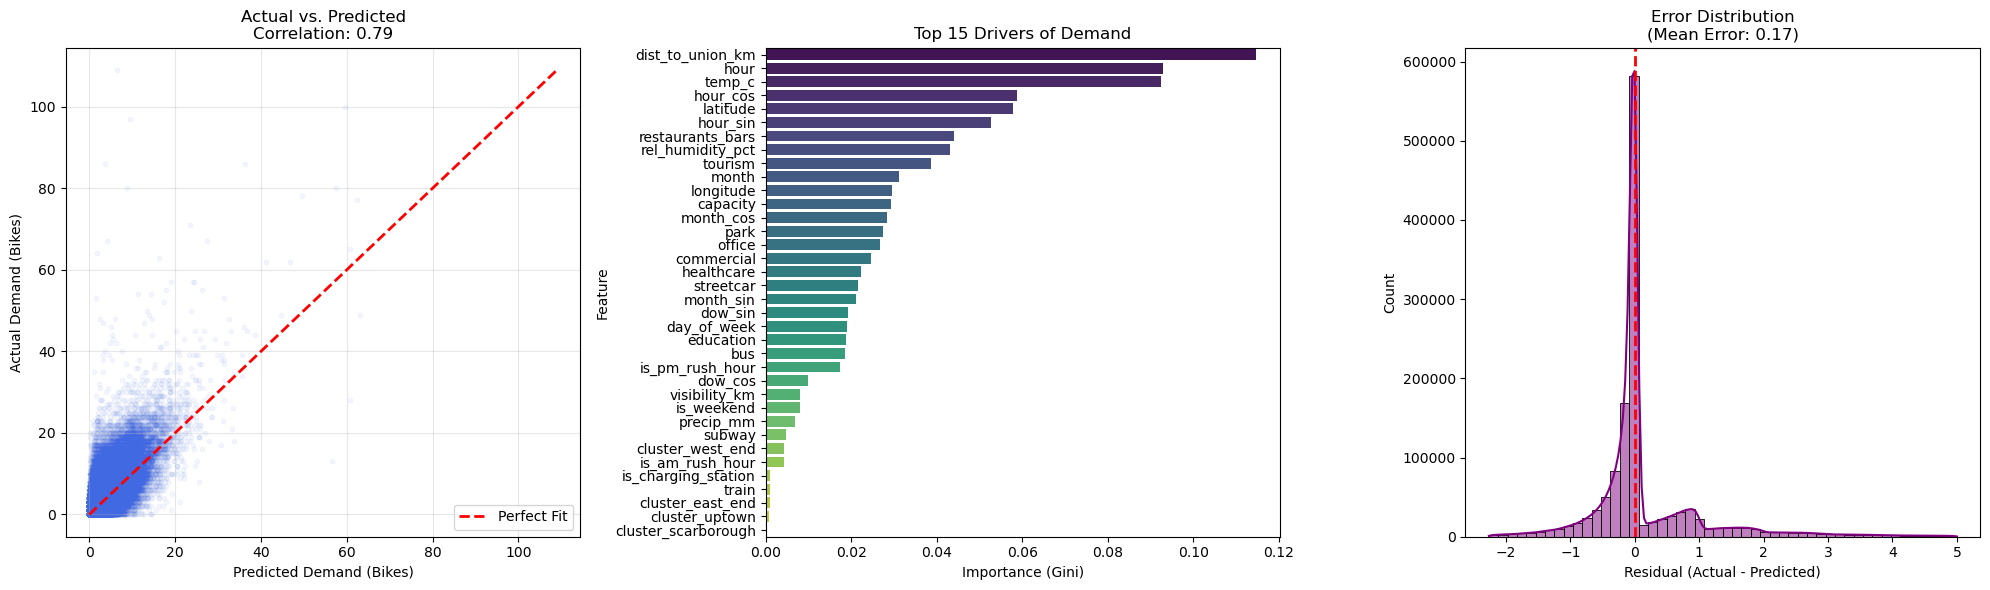

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. PREPARE DATA ---
# Ensure we are using the Real Scale arrays we created earlier
actuals = y_test_real
preds = y_pred_full_test_real
residuals = actuals - preds

# --- 2. SETUP PLOT ---
plt.figure(figsize=(20, 6))

# --- PLOT A: Actual vs. Predicted (The "Truth" Chart) ---
plt.subplot(1, 3, 1)
# Use alpha=0.05 because you have >100k points. Solid dots would look like a blob.
plt.scatter(preds, actuals, alpha=0.05, color='royalblue', s=10)

# Add the perfect 45-degree line
max_val = max(actuals.max(), preds.max())
plt.plot([0, max_val], [0, max_val], '--', color='red', linewidth=2, label='Perfect Fit')

plt.xlabel('Predicted Demand (Bikes)')
plt.ylabel('Actual Demand (Bikes)')
plt.title(f'Actual vs. Predicted\nCorrelation: {np.corrcoef(actuals, preds)[0,1]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

# --- PLOT B: Feature Importance (The "Logic" Chart) ---
plt.subplot(1, 3, 2)

# Extract importances from the Full Model
importances = rf_model_full.feature_importances_
feature_names = X_train_full.columns

# Create a DataFrame to sort them
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False) # Top 15 only

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top Drivers of Demand')
plt.xlabel('Importance (Gini)')

# --- PLOT C: Residual Distribution (The "Bias" Chart) ---
plt.subplot(1, 3, 3)
# We crop outliers for visibility (showing middle 98% of errors)
p01 = np.percentile(residuals, 1)
p99 = np.percentile(residuals, 99)
clipped_residuals = residuals[(residuals > p01) & (residuals < p99)]

sns.histplot(clipped_residuals, bins=50, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Error Distribution\n(Mean Error: {np.mean(residuals):.2f})')
plt.xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

## XGBoost

### Device Setup

In [16]:
# 1. Detect Device
# We use PyTorch to check for Nvidia GPU (CUDA) availability
if torch.cuda.is_available():
    print(f"NVIDIA GPU Detected: {torch.cuda.get_device_name(0)}")
    target_device = "cuda"
    n_jobs_xgb = 1  # GPU handles the parallelism internally, so we set CPU jobs to 1
else:
    print("No NVIDIA GPU found. Using CPU.")
    target_device = "cpu"
    n_jobs_xgb = 6  # Set to 4 or 6 based on your 25GB RAM

print(f"Models will run on: {target_device.upper()}")

No NVIDIA GPU found. Using CPU.
Models will run on: CPU


### Hyperparameter Tuning

In [25]:
print("\n--- Tuning XGBoost on Sample Data ---")

# XGBoost specific hyperparameters
param_dist = {
    'n_estimators': [1500, 2000, 3000],
    'learning_rate': [0.05, 0.1],   # Lower rate + more trees usually wins
    'max_depth': [8, 10, 12, 14],             # XGBoost prefers shallower trees than RF
    'subsample': [0.8, 0.9],         # Row sampling to prevent overfitting
    'colsample_bytree': [0.8, 0.9],   # Feature sampling (like max_features in RF)
    'min_child_weight': [1, 3, 5],      # Minimum sum of instance weight needed in a child
    'gamma': [0, 0.1],                   # minimum loss reduction to make a split
    'reg_lambda': [1, 3]                # L2 regularization strength
}

xgb_tuner = XGBRegressor(
    device=target_device,
    random_state=42, 
    n_jobs=n_jobs_xgb,
    objective='reg:squarederror' # Explicitly set objective for regression
)

random_search = RandomizedSearchCV(
    estimator=xgb_tuner,
    param_distributions=param_dist,
    n_iter=20,           # XGB is faster than RF, so we can try a few more combos
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=2
)

random_search.fit(X_train_sample, y_train_sample)
best_params_xgb = random_search.best_params_
print(f"Best Parameters: {best_params_xgb}")


--- Tuning XGBoost on Sample Data ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/opt/anaconda3/envs/DS3000env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'subsample': 0.9, 'reg_lambda': 3, 'n_estimators': 1500, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


### Training and Evaluation

In [33]:
# --- Model A: Trained on Sample Data ---
print("\n--- Training XGBoost on Sample Data ---")
xgb_model_sample = XGBRegressor(
    **best_params_xgb,
    random_state=42,
    n_jobs=n_jobs_xgb, 
    objective='reg:squarederror',
    tree_method='hist' 
)
xgb_model_sample.fit(X_train_sample, y_train_sample)

# --- Model B: Trained on Full Data ---
print("\n--- Training XGBoost on Full Data ---")
xgb_model_full = XGBRegressor(
    **best_params_xgb, 
    random_state=42, 
    n_jobs=n_jobs_xgb, 
    objective='reg:squarederror',
    tree_method='hist' 
)
xgb_model_full.fit(X_train_full, y_train_full)


--- Training XGBoost on Sample Data ---

--- Training XGBoost on Full Data ---


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Generate Predictions

In [43]:
# --- 1. GENERATE PREDICTIONS (Log Scale) ---
# Sample Model
y_pred_sample_train_log = xgb_model_sample.predict(X_train_sample)
y_pred_sample_val_log  = xgb_model_sample.predict(X_val)

# Full Model
y_pred_full_train_log = xgb_model_full.predict(X_train_full)
y_pred_full_val_log  = xgb_model_full.predict(X_val)

# --- 2. INVERSE TRANSFORM (Log -> Real Bikes) & CLAMP ---
# We use np.expm1 because the target was Log(1+x)
# We use np.maximum(..., 0) because XGBoost can predict negative numbers

# Sample Model Real
y_pred_sample_train_real = np.maximum(np.expm1(y_pred_sample_train_log), 0)
y_pred_sample_val_real  = np.maximum(np.expm1(y_pred_sample_val_log), 0)

# Full Model Real
y_pred_full_train_real   = np.maximum(np.expm1(y_pred_full_train_log), 0)
y_pred_full_val_real    = np.maximum(np.expm1(y_pred_full_val_log), 0)

# --- 3. INVERSE TRANSFORM ACTUALS ---
# Convert ground truth back to real bikes for fair comparison
y_train_sample_real = np.expm1(y_train_sample)
y_train_full_real   = np.expm1(y_train_full)
y_val_real         = np.expm1(y_val)

### Metrics and Evaluation

In [44]:
# --- 4. CALCULATE METRICS (Real Scale) ---
# Sample Model Scores
rmse_sample_train = np.sqrt(mean_squared_error(y_train_sample_real, y_pred_sample_train_real))
r2_sample_train   = r2_score(y_train_sample_real, y_pred_sample_train_real)

rmse_sample_val  = np.sqrt(mean_squared_error(y_val_real, y_pred_sample_val_real))
r2_sample_val    = r2_score(y_val_real, y_pred_sample_val_real)

# Full Model Scores
rmse_full_train   = np.sqrt(mean_squared_error(y_train_full_real, y_pred_full_train_real))
r2_full_train     = r2_score(y_train_full_real, y_pred_full_train_real)

rmse_full_val    = np.sqrt(mean_squared_error(y_val_real, y_pred_full_val_real))
r2_full_val      = r2_score(y_val_real, y_pred_full_val_real)

# --- 5. PRINT REPORT ---
print("\n" + "="*65)
print("XGBOOST CONFIGURATION (Best Params)")
print("="*65)
try:
    for param, value in best_params_xgb.items():
        print(f"{param:<25}: {value}")
except NameError:
    print("best_params_xgb not defined")

print("\n" + "="*65)
print(f"{'METRIC (Real Scale)':<20} | {'XGB (Sample Trained)':<20} | {'XGB (Full Trained)':<20}")
print("="*65)
print(f"{'Train RMSE':<20} | {rmse_sample_train:<20.4f} | {rmse_full_train:<20.4f}")
print(f"{'Val RMSE':<20} | {rmse_sample_val:<20.4f} | {rmse_full_val:<20.4f}")
print("-" * 65)
print(f"{'Train R^2':<20} | {r2_sample_train:<20.4f} | {r2_full_train:<20.4f}")
print(f"{'Val R^2':<20} | {r2_sample_val:<20.4f} | {r2_full_val:<20.4f}")
print("="*65)


XGBOOST CONFIGURATION (Best Params)
subsample                : 0.9
reg_lambda               : 3
n_estimators             : 1500
min_child_weight         : 5
max_depth                : 10
learning_rate            : 0.05
gamma                    : 0.1
colsample_bytree         : 0.8

METRIC (Real Scale)  | XGB (Sample Trained) | XGB (Full Trained)  
Train RMSE           | 0.9852               | 1.1569              
Val RMSE             | 1.3231               | 1.2832              
-----------------------------------------------------------------
Train R^2            | 0.7483               | 0.6543              
Val R^2              | 0.5666               | 0.5923              


### Final Test

In [45]:
# --- 1. GENERATE PREDICTIONS ON TEST SET (Log Scale) ---
# Sample Model
y_pred_sample_test_log = xgb_model_sample.predict(X_test)
# Full Model
y_pred_full_test_log = xgb_model_full.predict(X_test)

# --- 2. INVERSE TRANSFORM (Unclamped first) ---
# We calculate the raw 'Real Bike' count before applying the max(0) rule
# This allows us to see if XGBoost (which has no bounds) predicts negatives.
raw_pred_sample_test_xgb = np.expm1(y_pred_sample_test_log)
raw_pred_full_test_xgb   = np.expm1(y_pred_full_test_log)

# --- 3. DIAGNOSTIC: CHECK FOR NEGATIVE PREDICTIONS ---
# XGBoost is much more likely to produce negatives than RF
neg_sample = (raw_pred_sample_test_xgb < 0).sum()
neg_full   = (raw_pred_full_test_xgb < 0).sum()

pct_sample = (neg_sample / len(raw_pred_sample_test_xgb)) * 100
pct_full   = (neg_full / len(raw_pred_full_test_xgb)) * 100

# --- 4. CLAMP NEGATIVES (For Final Metrics) ---
# y_pred_sample_test_real = np.maximum(raw_pred_sample_test_xgb, 0)
# y_pred_full_test_real   = np.maximum(raw_pred_full_test_xgb, 0)
y_pred_sample_test_real = raw_pred_sample_test_xgb
y_pred_full_test_real   = raw_pred_full_test_xgb


# --- 5. INVERSE TRANSFORM ACTUALS ---
# Ensure y_test_real is defined
y_test_real = np.expm1(y_test)

# --- 6. CALCULATE TEST METRICS ---
# Helper function to keep code clean
def get_scores(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

# Sample Model Scores
rmse_sample_train, mae_sample_train, r2_sample_train = get_scores(y_train_sample_real, y_pred_sample_train_real)
rmse_sample_val, mae_sample_val, r2_sample_val     = get_scores(y_val_real, y_pred_sample_val_real)
rmse_sample_test, mae_sample_test, r2_sample_test   = get_scores(y_test_real, y_pred_sample_test_real)

# Full Model Scores
rmse_full_train, mae_full_train, r2_full_train = get_scores(y_train_full_real, y_pred_full_train_real)
rmse_full_val, mae_full_val, r2_full_val     = get_scores(y_val_real, y_pred_full_val_real)
rmse_full_test, mae_full_test, r2_full_test   = get_scores(y_test_real, y_pred_full_test_real)

# --- 5. PRINT REPORT ---
print("\n" + "="*65)
print("XGBOOST CONFIGURATION (Best Params)")
print("="*65)
try:
    for param, value in best_params_xgb.items():
        print(f"{param:<25}: {value}")
except NameError:
    print("best_params_xgb not defined")

print("\n" + "="*65)
print("DIAGNOSTICS (Negative Predictions Check)")
print("="*65)
print(f"Sample Model: {neg_sample} negatives ({pct_sample:.2f}%)")
print(f"Full Model:   {neg_full} negatives ({pct_full:.2f}%)")

print("\n" + "="*65)
print(f"{'METRIC (Real Scale)':<20} | {'XGB (Sample Trained)':<20} | {'XGB (Full Trained)':<20}")
print("="*65)
# RMSE
print(f"{'Train RMSE':<20} | {rmse_sample_train:<20.4f} | {rmse_full_train:<20.4f}")
print(f"{'Val RMSE':<20} | {rmse_sample_val:<20.4f} | {rmse_full_val:<20.4f}")
print(f"{'Test RMSE':<20} | {rmse_sample_test:<20.4f} | {rmse_full_test:<20.4f}")
print("-" * 65)
# MAE (New)
print(f"{'Train MAE':<20} | {mae_sample_train:<20.4f} | {mae_full_train:<20.4f}")
print(f"{'Val MAE':<20} | {mae_sample_val:<20.4f} | {mae_full_val:<20.4f}")
print(f"{'Test MAE':<20} | {mae_sample_test:<20.4f} | {mae_full_test:<20.4f}")
print("-" * 65)
# R2
print(f"{'Train R^2':<20} | {r2_sample_train:<20.4f} | {r2_full_train:<20.4f}")
print(f"{'Val R^2':<20} | {r2_sample_val:<20.4f} | {r2_full_val:<20.4f}")
print(f"{'Test R^2':<20} | {r2_sample_test:<20.4f} | {r2_full_test:<20.4f}")
print("="*65)


XGBOOST CONFIGURATION (Best Params)
subsample                : 0.9
reg_lambda               : 3
n_estimators             : 1500
min_child_weight         : 5
max_depth                : 10
learning_rate            : 0.05
gamma                    : 0.1
colsample_bytree         : 0.8

DIAGNOSTICS (Negative Predictions Check)
Sample Model: 163654 negatives (12.22%)
Full Model:   146306 negatives (10.93%)

METRIC (Real Scale)  | XGB (Sample Trained) | XGB (Full Trained)  
Train RMSE           | 0.9852               | 1.1569              
Val RMSE             | 1.3231               | 1.2832              
Test RMSE            | 1.2917               | 1.2428              
-----------------------------------------------------------------
Train MAE            | 0.4418               | 0.5244              
Val MAE              | 0.5860               | 0.5679              
Test MAE             | 0.5824               | 0.5631              
------------------------------------------------------------

### Visualizations

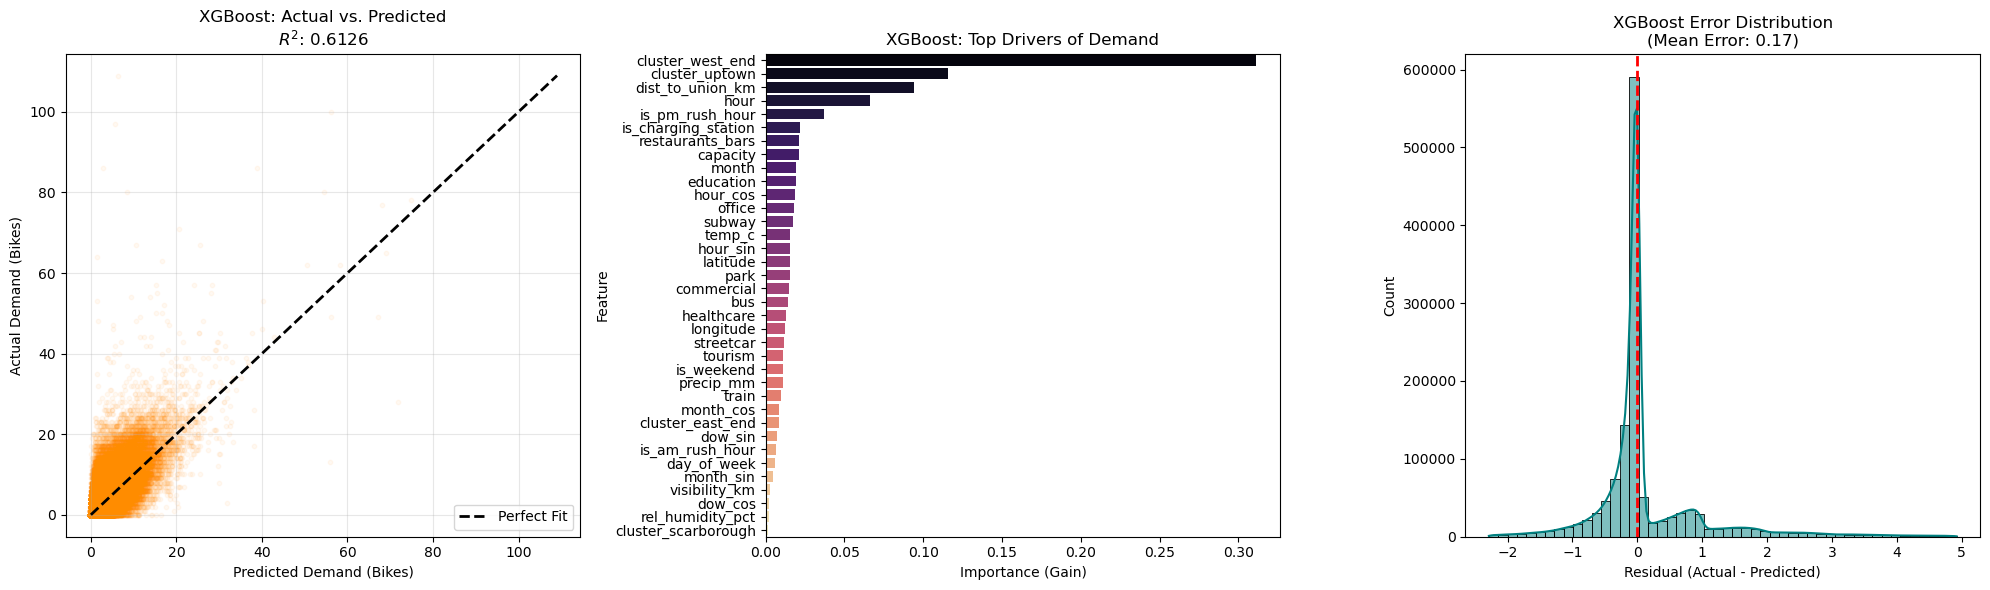

In [48]:
# --- 1. PREPARE DATA ---
# Use the XGBoost predictions we generated in the previous step
actuals = y_test_real
preds = y_pred_full_test_real  # <--- Updated for XGBoost
residuals = actuals - preds

# --- 2. SETUP PLOT ---
plt.figure(figsize=(20, 6))

# --- PLOT A: Actual vs. Predicted (The "Truth" Chart) ---
plt.subplot(1, 3, 1)
# Use alpha=0.05 because you have >100k points.
plt.scatter(preds, actuals, alpha=0.05, color='darkorange', s=10) # Changed color to distinguish from RF

# Add the perfect 45-degree line
max_val = max(actuals.max(), preds.max())
plt.plot([0, max_val], [0, max_val], '--', color='black', linewidth=2, label='Perfect Fit')

plt.xlabel('Predicted Demand (Bikes)')
plt.ylabel('Actual Demand (Bikes)')
# Using R^2 in title as discussed (safer than correlation)
plt.title(f'XGBoost: Actual vs. Predicted\n$R^2$: {r2_full_test:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# --- PLOT B: Feature Importance (The "Logic" Chart) ---
plt.subplot(1, 3, 2)

# Extract importances from the XGBoost Model
importances = xgb_model_full.feature_importances_ # <--- Works the same as RF
feature_names = X_train_full.columns

# Create a DataFrame to sort them
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma', hue='Feature', legend=False)
plt.title('XGBoost: Top Drivers of Demand')
plt.xlabel('Importance (Gain)') # XGBoost default is usually Gain/Weight

# --- PLOT C: Residual Distribution (The "Bias" Chart) ---
plt.subplot(1, 3, 3)
# We crop outliers for visibility (showing middle 98% of errors)
p01 = np.percentile(residuals, 1)
p99 = np.percentile(residuals, 99)
clipped_residuals = residuals[(residuals > p01) & (residuals < p99)]

sns.histplot(clipped_residuals, bins=50, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'XGBoost Error Distribution\n(Mean Error: {np.mean(residuals):.2f})')
plt.xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()